### TGP Asteroids 2 - Astrometry

Author: Matylda Rejus  <br>
Date: January 2026

#### First, load in the necessary libraries

In [3]:
# Load in the packages
import numpy as np
# Set up matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

from astropy.io import fits
import astropy.wcs as WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
# Set up scipy
from scipy.optimize import curve_fit



#### Load in files from three separate nights

*Note: Requires locally saved .fits images.*

In [2]:
# Load in the image files from three separate nights

image_files = ["/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167140_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_19_20_56_12.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167827_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_22_19_48_43.fits"]

# Open the FITS file
hdul = fits.open(image_files[0])
hdul.info()

# Inspect the first image
image_data = hdul[0].data
print(image_data)
plt.imshow(image_data)
plt.colorbar()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits'

#### Extract observation times for each image in the utc format

In [ ]:
times = []
times_utc = []

for i in range(len(image_files)):
    hdul = fits.open(image_files[i])
    t_obs = hdul[0].header['DATE-OBS']
    times_utc.append(t_obs)
    t_obs_jd = Time(t_obs, format='isot', scale='utc').jd
    times.append(t_obs_jd)

print(times_utc)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 347.312822564  -14.8957900285  
CRPIX : 908.418556213  1643.62734985  
CD1_1 CD1_2  : 0.000261683035088  8.71243099371e-06  
CD2_1 CD2_2  : 8.61954322596e-06  -0.000261701934288  
NAXIS : 2048  2048
2025-10-09T21:34:07.7287975
['2025-10-09T21:34:07.7287975', '2025-10-19T20:56:12.5418947', '2025-10-22T19:48:43.5988862']


a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


#### Convert the days utc format to fractional days required by Find_orb

### From here on, the rest of code extracts the information needed for finding orbital parameters by Find_ord

#### Convert the days to fractional days

In [ ]:
# Convert to days from utc format to fractional days 

obs_1 = 9 + (21 + 34/60 + 7/3600)/24
obs_2 = 19 + (20 + 56/60 + 12/3600)/24
obs_3 = 22 + (19 + 48/60 + 43/3600)/24

frac_days = [obs_1, obs_2, obs_3]
print(f"{float(frac_days[0]):.5f}, {float(frac_days[1]):.5f}, {float(frac_days[2]):.5f}")

9.89869, 19.87236, 22.82550


#### Locate the asteroid in ds9 and create a list of pixel coordinates

In [ ]:
# I ran the asteroid finding code in photometry.ipynb to adjust the positions

# Get a list of RA and Dec values for the three nights

ra_list = ['23:09:23.2', '23 06 16.2', '23 06 00.1']
dec_list = ['23 06 00.1', '-14 35 08.8', '-14 27 38.3']

ra_dec = SkyCoord(ra=ra_list*u.degree, dec=dec_list*u.degree, frame='icrs')

RA_hms = ra_dec.ra.to_string(unit=u.hourangle, sep=':',pad=True, precision=1) # format hms

Dec_dms = ra_dec.dec.to_string(unit=u.degree, sep=':',pad=True, precision=1) # format dms

print(RA_hms)
print(Dec_dms)


print(f"RA: {ra_list}, Dec: {dec_list}")

NameError: name 'SkyCoord' is not defined

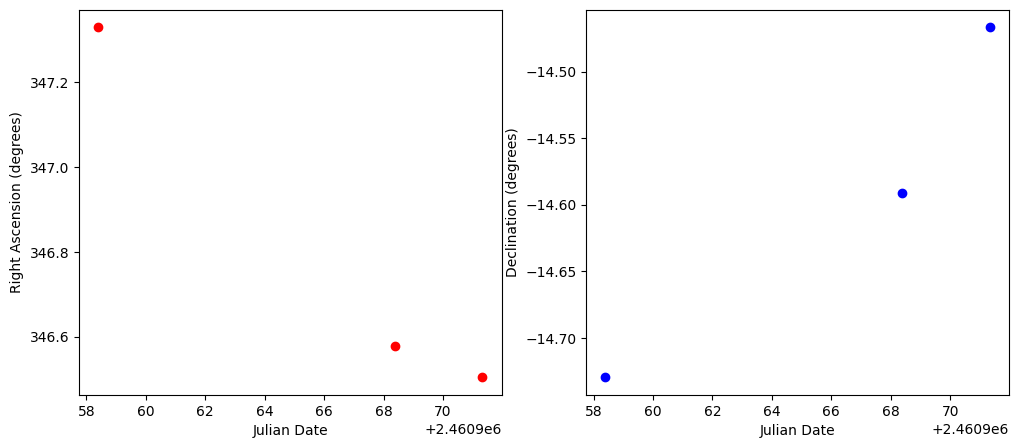

In [ ]:
# Now we have the times, RA, and Dec from across three different nights
# We can use these to fit the orbital parameters of the asteroid 

# Plot the observed RA and Dec separately over time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(times, ra_list, color='red', label='Observed RA')
axes[0].set_ylabel('Right Ascension (degrees)')
axes[0].set_xlabel('Julian Date')

axes[1].scatter(times, dec_list, color='blue', label='Observed Dec')
axes[1].set_ylabel('Declination (degrees)')
axes[1].set_xlabel('Julian Date')



plt.show()



# Now, solve for the orbital elements

In [ ]:
import poliastro
import orbitdeterminator
from orbitdeterminator.kep_determination import gauss_method as gm
from astropy.coordinates import EarthLocation, solar_system_ephemeris, get_body_barycentric

c:\Users\Matylda\anaconda3\envs\orbit\lib\site-packages\blessed\terminal.py:222: UserWarning: Failed to setupterm(kind='xterm-color'): Could not find terminal xterm-color
  warnings.warn(msg)


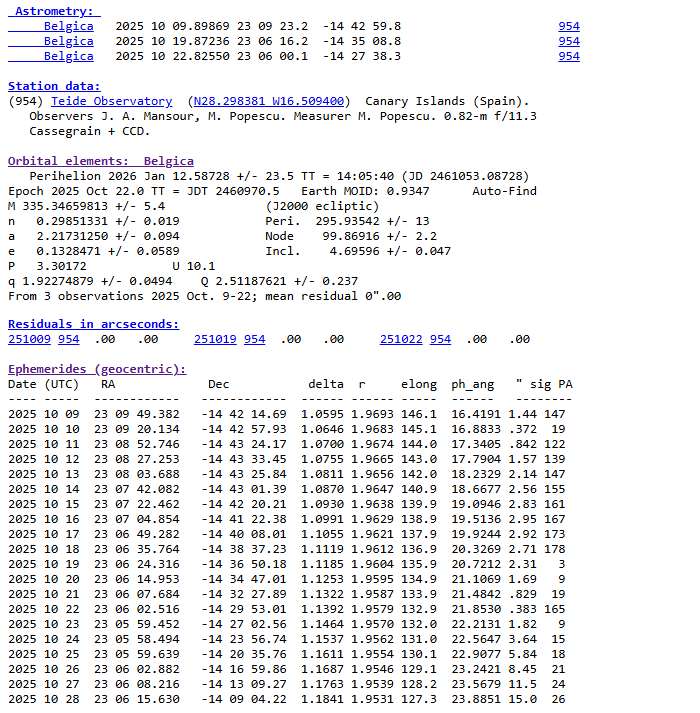

In [4]:
# Plotting parameters

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = True
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['figure.dpi'] = 130

## Plot the orbit (3D and 2D)

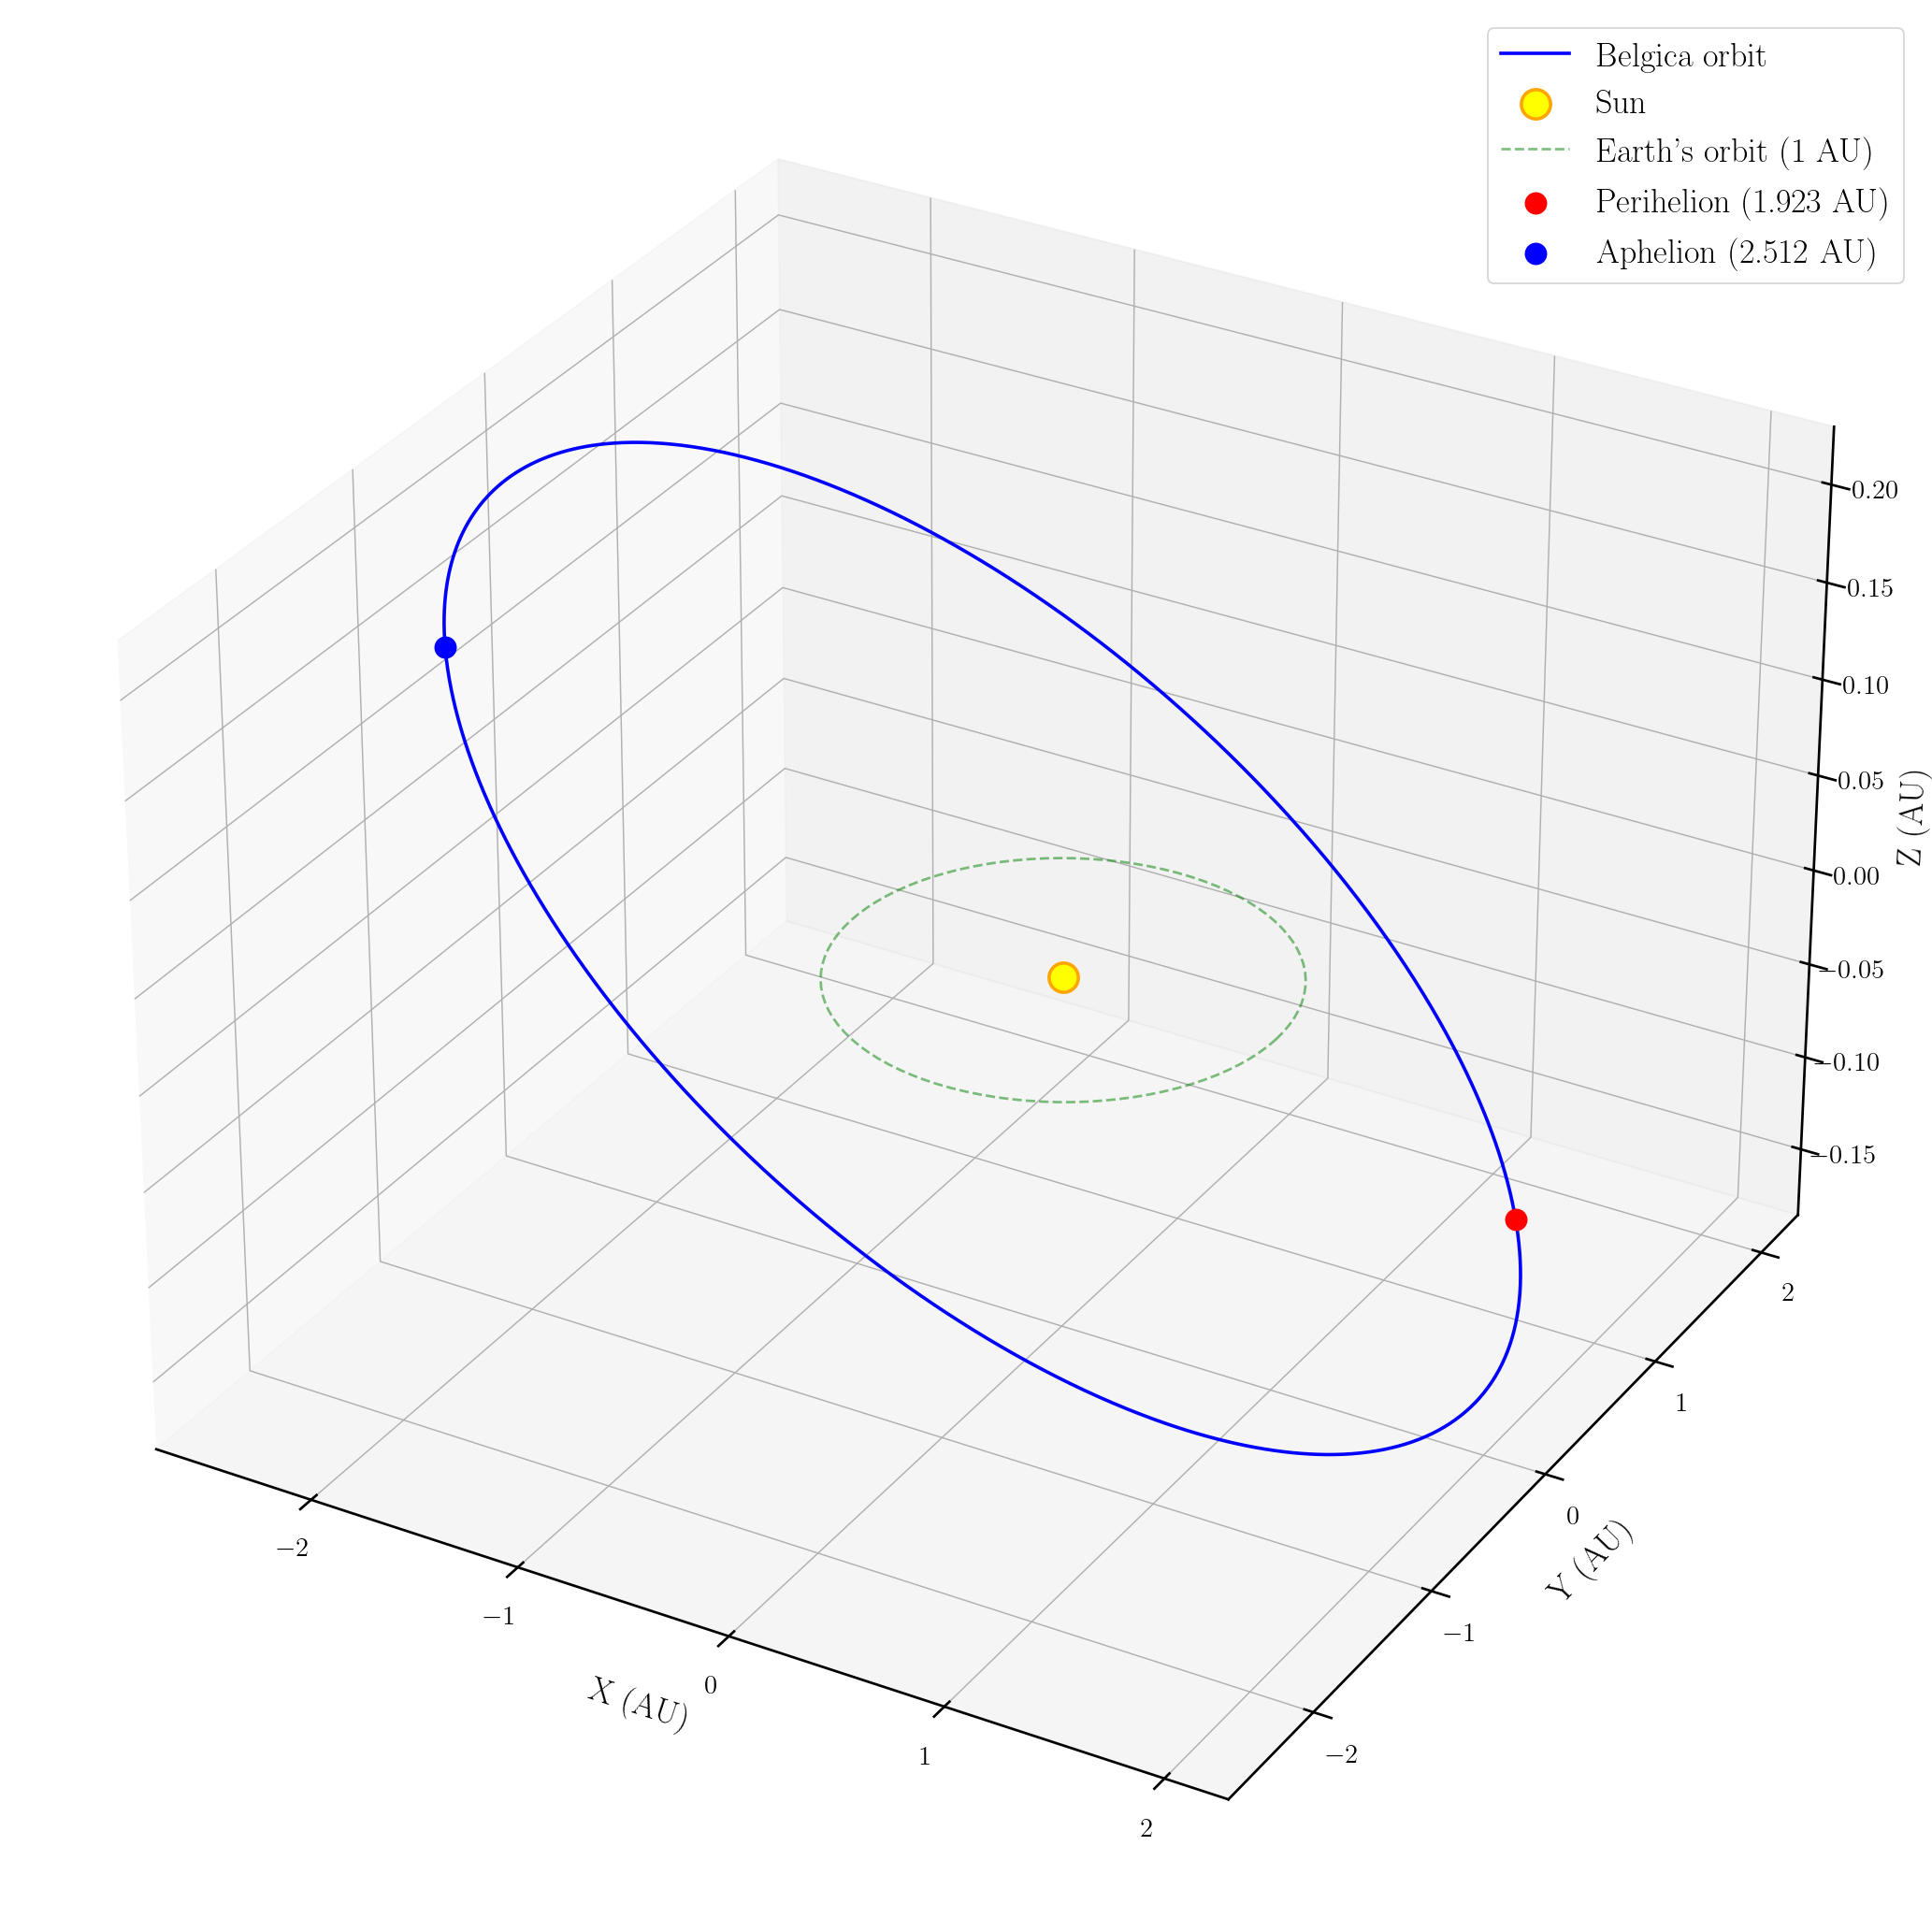

ORBITAL ELEMENTS - Asteroid Belgica
Semi-major axis (a):           2.21731250 AU
Eccentricity (e):              0.13284710
Inclination (i):               4.69596°
Arg. of perihelion (ω):        295.93542°
Long. of asc. node (Ω):        99.86916°
Mean anomaly at epoch (M₀):    335.34660°
Orbit type:                    ELLIPTICAL
Perihelion distance (q):       1.92274896 AU
Aphelion distance (Q):         2.51187604 AU
Orbital period (P):            3.3017 years
                               (1206.0 days)


In [11]:
a = 2.21731250  # semi-major axis (AU)
e = 0.1328471  # eccentricity (ELLIPTICAL orbit)
i = np.radians(4.69596)  # inclination (convert to radians)
omega = np.radians(295.93542)  # argument of perihelion (radians)
Omega = np.radians(99.86916)  # longitude of ascending node (radians)
M0 = 335.34659813  # mean anomaly at epoch (radians)

# Number of points for orbit
n_points = 1000

def solve_kepler(M, e, tol=1e-10):
    """Solve Kepler's equation M = E - e*sin(E) for eccentric anomaly E"""
    E = M  # initial guess
    for _ in range(100):
        E_new = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        if abs(E_new - E) < tol:
            return E_new
        E = E_new
    return E

# Generate orbit points
M = np.linspace(0, 2*np.pi, n_points)  # Mean anomaly
E = np.array([solve_kepler(m, e) for m in M])  # Eccentric anomaly

# Position in orbital plane
x_orb = a * (np.cos(E) - e)
y_orb = a * np.sqrt(1 - e**2) * np.sin(E)
z_orb = np.zeros_like(x_orb)

def rotate_orbit(x, y, z, omega, i, Omega):
    """Rotate from orbital plane to ecliptic EQUATORIAL coordinates
        Based on Orbits in 3D by H. Curtis
    """
    R = np.array([
        [np.cos(Omega)*np.cos(omega) - np.sin(Omega)*np.sin(omega)*np.cos(i),
         -np.cos(Omega)*np.sin(omega) - np.sin(Omega)*np.cos(omega)*np.cos(i),
         np.sin(Omega)*np.sin(i)],
        [np.sin(Omega)*np.cos(omega) + np.cos(Omega)*np.sin(omega)*np.cos(i),
         -np.sin(Omega)*np.sin(omega) + np.cos(Omega)*np.cos(omega)*np.cos(i),
         -np.cos(Omega)*np.sin(i)],
        [np.sin(omega)*np.sin(i),
         np.cos(omega)*np.sin(i),
         np.cos(i)]
    ])
    
    positions = np.array([x, y, z])
    rotated = R @ positions
    return rotated[0], rotated[1], rotated[2]

# Rotate to equatorial coordinates
x, y, z = rotate_orbit(x_orb, y_orb, z_orb, omega, i, Omega)

# Create 3D plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot the orbit
ax.plot(x, y, z, 'b-', linewidth=2, label='Belgica orbit')

# Plot the Sun
ax.scatter([0], [0], [0], color='yellow', s=300, marker='o', 
           edgecolors='orange', linewidths=2, label='Sun')

# Plot Earth's orbit for reference
theta_earth = np.linspace(0, 2*np.pi, 100)
x_earth = np.cos(theta_earth)
y_earth = np.sin(theta_earth)
z_earth = np.zeros_like(theta_earth)
ax.plot(x_earth, y_earth, z_earth, 'g--', alpha=0.5, linewidth=1.5, label="Earth's orbit (1 AU)")

# Plot perihelion and aphelion
q = a * (1 - e)  # perihelion distance
Q = a * (1 + e)  # aphelion distance

# Perihelion at theta = 0
x_peri, y_peri, z_peri = rotate_orbit(np.array([q]), np.array([0]), 
                                       np.array([0]), omega, i, Omega)
ax.scatter(x_peri, y_peri, z_peri, color='red', s=150, 
           marker='o', label=f'Perihelion ({q:.3f} AU)', zorder=5)

# Aphelion at theta = pi
x_aph, y_aph, z_aph = rotate_orbit(np.array([-Q]), np.array([0]), 
                                    np.array([0]), omega, i, Omega)
ax.scatter(x_aph, y_aph, z_aph, color='blue', s=150, 
           marker='o', label=f'Aphelion ({Q:.3f} AU)', zorder=5)

# Labels and formatting
ax.set_xlabel('X (AU)' , labelpad=15)
ax.set_ylabel('Y (AU)', labelpad=15)
ax.set_zlabel('Z (AU)', labelpad=15)
#ax.set_title('Orbit of Asteroid Belgica', fontsize=14,)

ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.tick_params(axis='z', pad=8)

ax.legend(loc='upper right')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print orbital information
print("=" * 60)
print("ORBITAL ELEMENTS - Asteroid Belgica")
print("=" * 60)
print(f"Semi-major axis (a):           {a:.8f} AU")
print(f"Eccentricity (e):              {e:.8f}")
print(f"Inclination (i):               {np.degrees(i):.5f}°")
print(f"Arg. of perihelion (ω):        {np.degrees(omega):.5f}°")
print(f"Long. of asc. node (Ω):        {np.degrees(Omega):.5f}°")
print(f"Mean anomaly at epoch (M₀):    {M0:.5f}°")
print("=" * 60)
print(f"Orbit type:                    ELLIPTICAL")
print(f"Perihelion distance (q):       {q:.8f} AU")
print(f"Aphelion distance (Q):         {Q:.8f} AU")
print(f"Orbital period (P):            {np.sqrt(a**3):.4f} years")
print(f"                               ({np.sqrt(a**3)*365.25:.1f} days)")
print("=" * 60)

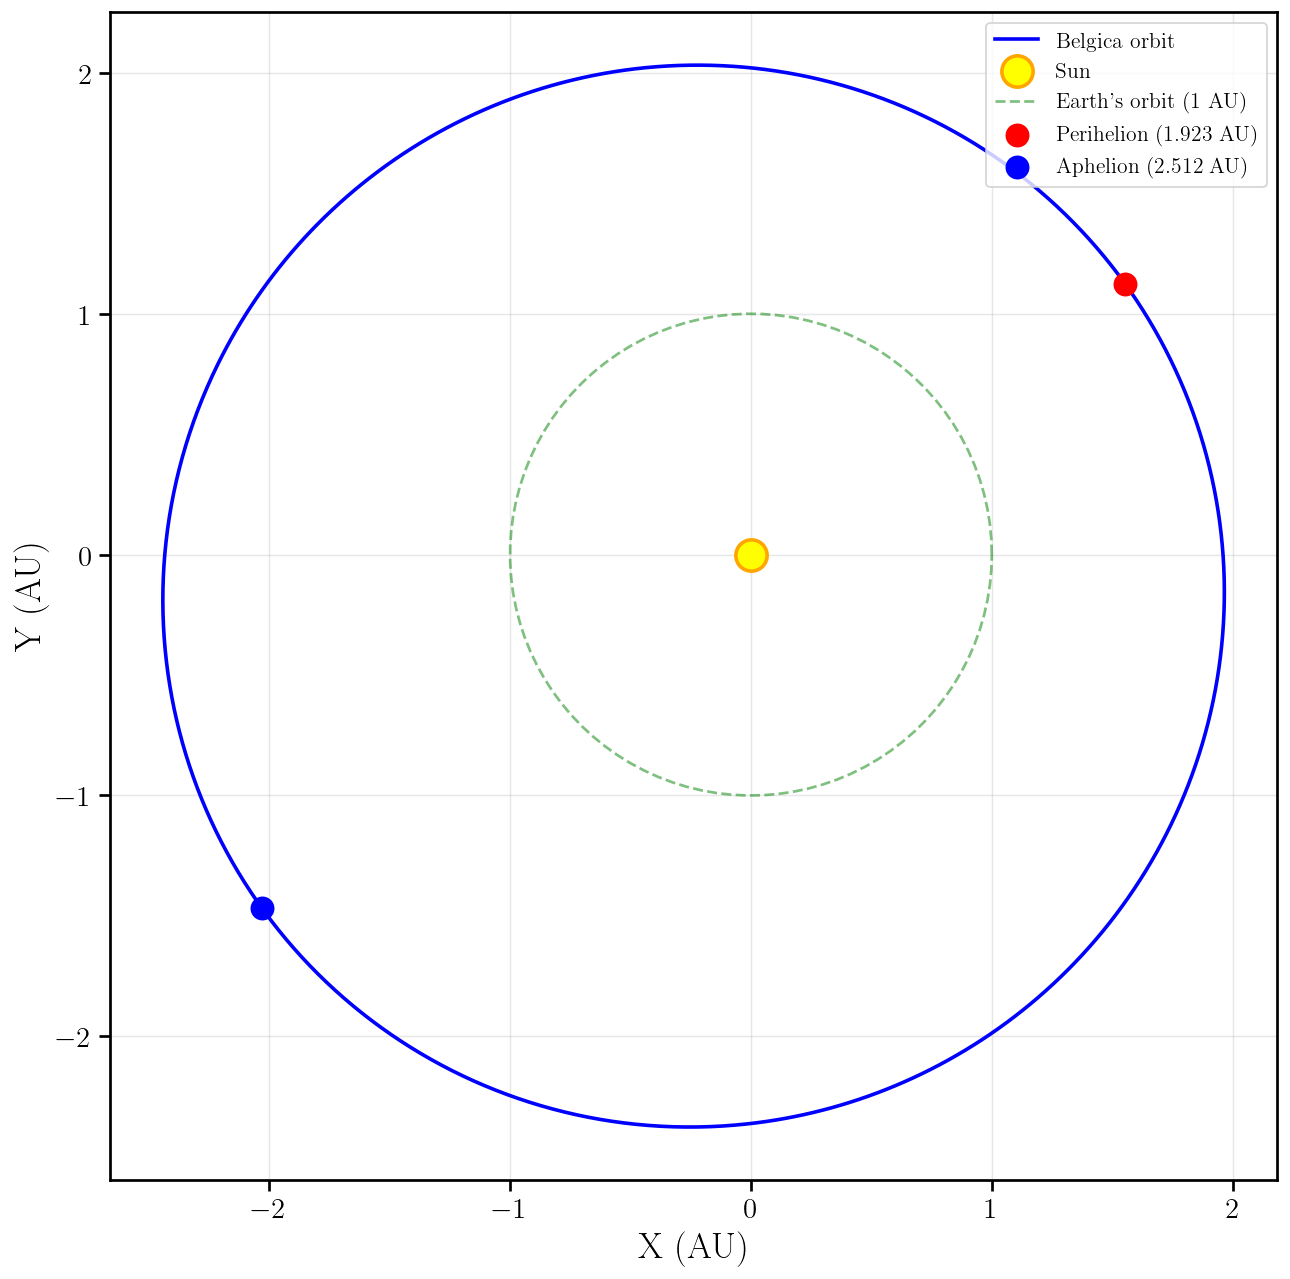

In [13]:
# Create 2D plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(x, y, 'b-', linewidth=2, label='Belgica orbit')

ax.scatter([0], [0], color='yellow', s=300, marker='o', 
           edgecolors='orange', linewidths=2, label='Sun', zorder=5)
# Earth
theta_earth = np.linspace(0, 2*np.pi, 100)
x_earth = np.cos(theta_earth)
y_earth = np.sin(theta_earth)
ax.plot(x_earth, y_earth, 'g--', alpha=0.5, linewidth=1.5, label="Earth's orbit (1 AU)")

# Plot perihelion and aphelion
q = a * (1 - e)
Q = a * (1 + e)

x_peri, y_peri, z_peri = rotate_orbit(np.array([q]), np.array([0]), 
                                       np.array([0]), omega, i, Omega)
ax.scatter(x_peri, y_peri, color='red', s=150, 
           marker='o', label=f'Perihelion ({q:.3f} AU)', zorder=5)

x_aph, y_aph, z_aph = rotate_orbit(np.array([-Q]), np.array([0]), 
                                    np.array([0]), omega, i, Omega)
ax.scatter(x_aph, y_aph, color='blue', s=150, 
           marker='o', label=f'Aphelion ({Q:.3f} AU)', zorder=5)

# Labels and formatting
ax.set_xlabel('X (AU)')
ax.set_ylabel('Y (AU)')
#ax.set_title('Orbit of Asteroid Belgica (2D view from ecliptic north pole)', 
#fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()